<a href="https://colab.research.google.com/github/Bhavyaa16/Celebel-excelence-internship-assignments/blob/main/week5_BhavyaChauthramani.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.20.0


In [2]:
corpus = '''
Let me introduce you to my party people in the club, huh
I'm loose (I'm loose)
And everybody knows I get off the chain
Baby, it's the truth (it's the truth)
I'm like Inception
I play with your brain
So don't sleep or snooze (snooze)
I don't play no games so d-don't-d-don't-d-don't
Don't get it confused, no
'Cause you will lose, yeah
Now, now pump-pu-pump-pu-pu-pu-pump it up
And back it up like a Tonka truck
Dale
If you go hard, you gotta get on the floor (hey)
If you're a party freak then step on the floor (yeah)
If you're an animal then tear up the floor
Break a sweat on the floor
Yeah, we work on the floor (dale)
Don't stop, keep it movin', put your drinks up (woo)
Pick your body up and drop it on the floor (hey)
Let the rhythm change your world on the floor
You know we're running sh- tonight on the floor
Brazil, Morocco, London to Ibiza
Straight to LA, New York, Vegas to Africa (dale)
Dance the night away
Live your life and stay young on the floor
Dance the night away
Grab somebody, drink a little more
(Así mismo, así me gusta)
(Así me gusta, así me gusta)
La, la-la-la-la, la-la-la-la-la-la-la-la-la
Tonight we gon' be it on the floor (woo)
La, la-la-la-la, la-la-la-la-la-la-la-la-la
Tonight we gon' be it on the floor (yeah, that's right)
'''
print(corpus)



Let me introduce you to my party people in the club, huh
I'm loose (I'm loose)
And everybody knows I get off the chain
Baby, it's the truth (it's the truth)
I'm like Inception
I play with your brain
So don't sleep or snooze (snooze)
I don't play no games so d-don't-d-don't-d-don't
Don't get it confused, no
'Cause you will lose, yeah
Now, now pump-pu-pump-pu-pu-pu-pump it up
And back it up like a Tonka truck
Dale
If you go hard, you gotta get on the floor (hey)
If you're a party freak then step on the floor (yeah)
If you're an animal then tear up the floor
Break a sweat on the floor
Yeah, we work on the floor (dale)
Don't stop, keep it movin', put your drinks up (woo)
Pick your body up and drop it on the floor (hey)
Let the rhythm change your world on the floor
You know we're running sh- tonight on the floor
Brazil, Morocco, London to Ibiza
Straight to LA, New York, Vegas to Africa (dale)
Dance the night away
Live your life and stay young on the floor
Dance the night away
Grab somebody

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

input_sequences = []

for line in corpus.split("\n"):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("Vocabulary Size:", total_words)
print("Max Sequence Length:", max_len)
print("Training Samples:", len(X))


Vocabulary Size: 118
Max Sequence Length: 14
Training Samples: 232


In [4]:
EMBED_DIM = 64
EPOCHS = 200
OPTIMIZER = 'adam'


In [5]:
rnn_model = Sequential([
    Embedding(total_words, EMBED_DIM, input_length=max_len-1),
    SimpleRNN(64, return_sequences=True),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    optimizer=OPTIMIZER,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(X, y, epochs=EPOCHS, verbose=0)
print("RNN Training Complete")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


RNN Training Complete


In [6]:
lstm_model = Sequential([
    Embedding(total_words, EMBED_DIM, input_length=max_len-1),
    LSTM(64, return_sequences=True),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(
    optimizer=OPTIMIZER,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(X, y, epochs=EPOCHS, verbose=0)
print("LSTM Training Complete")


LSTM Training Complete


In [7]:
gru_model = Sequential([
    Embedding(total_words, EMBED_DIM, input_length=max_len-1),
    GRU(64, return_sequences=True),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(
    optimizer=OPTIMIZER,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

gru_history = gru_model.fit(X, y, epochs=EPOCHS, verbose=0)
print("GRU Training Complete")


GRU Training Complete


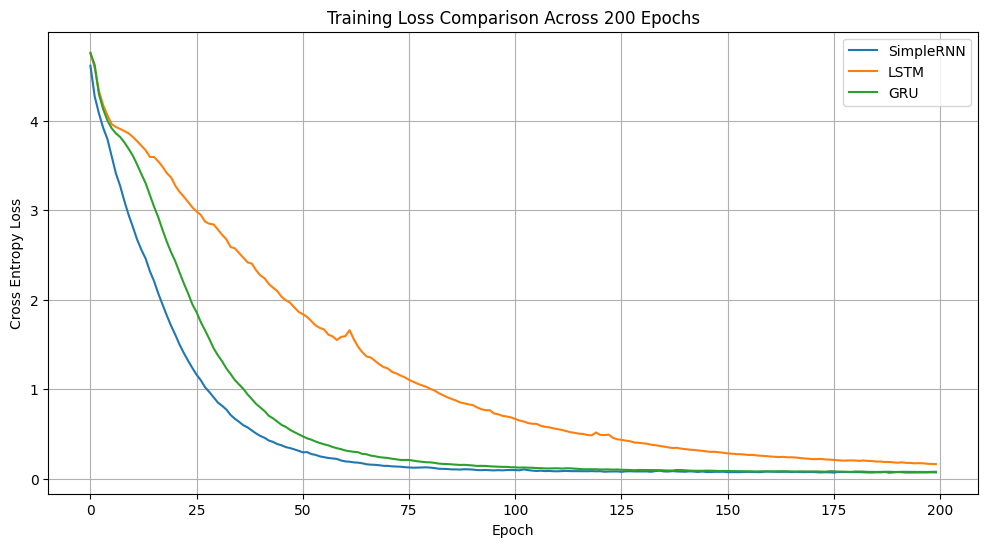

In [8]:
plt.figure(figsize=(12,6))

plt.plot(rnn_history.history['loss'], label='SimpleRNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')

plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.title('Training Loss Comparison Across 200 Epochs')
plt.legend()
plt.grid(True)

plt.show()


In [9]:
def generate_text(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text


In [10]:
seed_phrase = "Brazil, Morocco, London"

print("RNN Output:")
print(generate_text(rnn_model, seed_phrase, 10))

print("\nLSTM Output:")
print(generate_text(lstm_model, seed_phrase, 10))

print("\nGRU Output:")
print(generate_text(gru_model, seed_phrase, 10))


RNN Output:
Brazil, Morocco, London to ibiza party gon' be it on the floor yeah

LSTM Output:
Brazil, Morocco, London to ibiza ibiza ibiza pu d d don't d don't

GRU Output:
Brazil, Morocco, London to ibiza ibiza ibiza people in in the club huh
